# Linear Regression Model — King County House Prices

**Notebook flow:** `EDA.ipynb` → data cleaning + exploratory analysis → saves `housing_clean.csv` → **this notebook** → feature engineering + linear regression modelling

This notebook picks up directly from `EDA.ipynb`. The dataset is already cleaned and explored. Every feature engineering decision in Section 3 is grounded in a specific EDA finding.

**Why Linear Regression?**  
Before using powerful ensemble methods, it is best practice to establish a **baseline** with a simpler, interpretable model. Linear Regression's coefficients have a direct dollar meaning — every number in the output tells a concrete business story. Its structural limitations on this dataset will directly justify the need for ensemble methods.

**What this notebook covers:**
1. **Feature Engineering** — translating EDA insights into model-ready features, including correlation analysis and VIF (multicollinearity) checks
2. **Simple Linear Regression** (`sqft_living` only) — lower-bound baseline
3. **Multiple Linear Regression** (all engineered features) — full linear model with OLS statistical output
4. **Residual analysis** — testing the four core linear regression assumptions
5. **Coefficient analysis** — every feature expressed in dollar terms
6. **Regularisation** — Ridge and Lasso as responses to multicollinearity
7. **Cross-validation** — confirming results generalise beyond the single split
8. **Model comparison** — linear regression vs ensemble results from `IronKaggle_Mini_Project.ipynb`

## 1. Imports and Setup

In [105]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load Cleaned Data

We load the dataset saved by `EDA.ipynb` (`../data/housing_clean.csv`). It already has:
- The 33-bedroom data-entry error removed → **21,612 rows** (from the original 21,613)
- `date` parsed into `sale_year` and `sale_month` then dropped
- No missing values, no duplicate rows
- `id` and `zipcode` retained in the file — how they are handled is decided here in the modelling notebook

In [106]:
# Load the cleaned dataset produced by EDA.ipynb
df = pd.read_csv('../data/housing_clean.csv')
print(f"Shape: {df.shape}")
print(f"Columns ({df.shape[1]}): {list(df.columns)}")
df.head()

Shape: (21612, 22)
Columns (22): ['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month']


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


---
## 3. Feature Engineering

The EDA established which features correlate most strongly with price and flagged multicollinearity risks. This section translates those findings into deliberate engineering decisions before any model is trained. A linear model cannot discover interactions or down-weight redundant features automatically — we must do this by hand.

### 3.1 EDA Insights That Drive Our Decisions

| EDA Finding | Source | Action |
|---|---|---|
| `sqft_living` r = 0.70 with price | Correlation heatmap | **Keep** — single strongest numeric predictor |
| `grade` r = 0.67 with price | Correlation heatmap | **Keep** — second strongest |
| `sqft_above` r = 0.88 with `sqft_living` | Correlation heatmap | **Remove** — severe multicollinearity (confirmed by VIF, Section 3.4) |
| `sqft_living15` r = 0.76 with `sqft_living` | Correlation heatmap | **Remove** — neighbour living size is largely redundant |
| `sqft_lot15` p = 0.162 in initial OLS run | OLS summary output | **Remove** — statistically non-significant |
| `yr_renovated` = 0 for ~96% of homes | EDA `describe()` | **Convert** to binary flag + recency metric; raw year is too sparse |
| `yr_built` ranges 1900–2015 | EDA `describe()` | **Replace** with `house_age` — age is directly interpretable; raw year is not |
| `sale_year` = 2014 or 2015 only | EDA cleaning output | **Remove after use** — used to compute `house_age`, then too low-variance to keep |
| Geographic north–south price gradient | lat/long scatter map | **Keep** `lat` + `long` — both carry spatial signal |
| `zipcode` as categorical identifier | EDA structure discussion | **One-hot encode** — treating it as an ordinal number would be statistically wrong |
| `sale_month` near-zero correlation | Heatmap + monthly stats table | **Keep with low expected weight** — model decides its contribution |

### 3.2 Engineering Plan

| New Feature | Calculation | What It Captures |
|---|---|---|
| `house_age` | `sale_year − yr_built` | Years since construction — newer homes tend to command a premium; more interpretable than a raw year |
| `is_renovated` | `1 if yr_renovated > 0, else 0` | Binary signal — the ≈4% of renovated homes may price differently |
| `renovation_age` | `sale_year − yr_renovated` (0 if never renovated) | For renovated homes: how recent was the work? Recent renovations add more value |
| `basement_flag` | `1 if sqft_basement > 0, else 0` | Presence of a basement often matters more than its exact square footage |
| `sqft_ratio` | `sqft_living / sqft_lot` | Living density — high = dense urban home, low = large rural lot |
| `bath_bed_ratio` | `bathrooms / bedrooms` | Quality proxy — more bathrooms per bedroom signals a higher-end, more spacious layout |

In [107]:
# 3. Feature Engineering ─────────────────────────────────────────────────────
df_model = df.copy()

# 3.2 Create derived features ──────────────────────────────────────────────
df_model["house_age"]      = df_model["sale_year"] - df_model["yr_built"]
df_model["is_renovated"]   = (df_model["yr_renovated"] > 0).astype(int)
df_model["renovation_age"] = np.where(
    df_model["yr_renovated"] > 0,
    df_model["sale_year"] - df_model["yr_renovated"],
    0
)
df_model["basement_flag"]  = (df_model["sqft_basement"] > 0).astype(int)
df_model["sqft_ratio"]     = (df_model["sqft_living"] / df_model["sqft_lot"]).round(4)
df_model["bath_bed_ratio"] = (
    df_model["bathrooms"] / df_model["bedrooms"].replace(0, np.nan)
).round(4).fillna(0)

# Drop columns superseded by new features ──────────────────────────────────
drop_early = ["id", "yr_built", "yr_renovated", "sale_year"]
drop_early = [c for c in drop_early if c in df_model.columns]
df_model.drop(columns=drop_early, inplace=True)

# Summary of new features ──────────────────────────────────────────────────
new_feats = ["house_age", "is_renovated", "renovation_age",
             "basement_flag", "sqft_ratio", "bath_bed_ratio"]
print("New feature summary statistics:")
display(df_model[new_feats].describe().T.round(2))
print(f"\nDropped (superseded by new features): {drop_early}")
print(f"Current shape: {df_model.shape[0]:,} rows × {df_model.shape[1]} columns "
      f"({df_model.shape[1]-1} features + price)")

New feature summary statistics:


,count,mean,std,min,25%,50%,75%,max
house_age,21612.0,43.32,29.38,-1.0,18.00,40.00,63.00,115.00
is_renovated,21612.0,0.04,0.20,0.0,0.00,0.00,0.00,1.00
renovation_age,21612.0,0.78,4.90,-1.0,0.00,0.00,0.00,80.00
basement_flag,21612.0,0.39,0.49,0.0,0.00,0.00,1.00,1.00
sqft_ratio,21612.0,0.32,0.27,0.0,0.16,0.25,0.41,4.65
bath_bed_ratio,21612.0,0.64,0.21,0.0,0.50,0.62,0.75,2.50



Dropped (superseded by new features): ['id', 'yr_built', 'yr_renovated', 'sale_year']
Current shape: 21,612 rows × 24 columns (23 features + price)


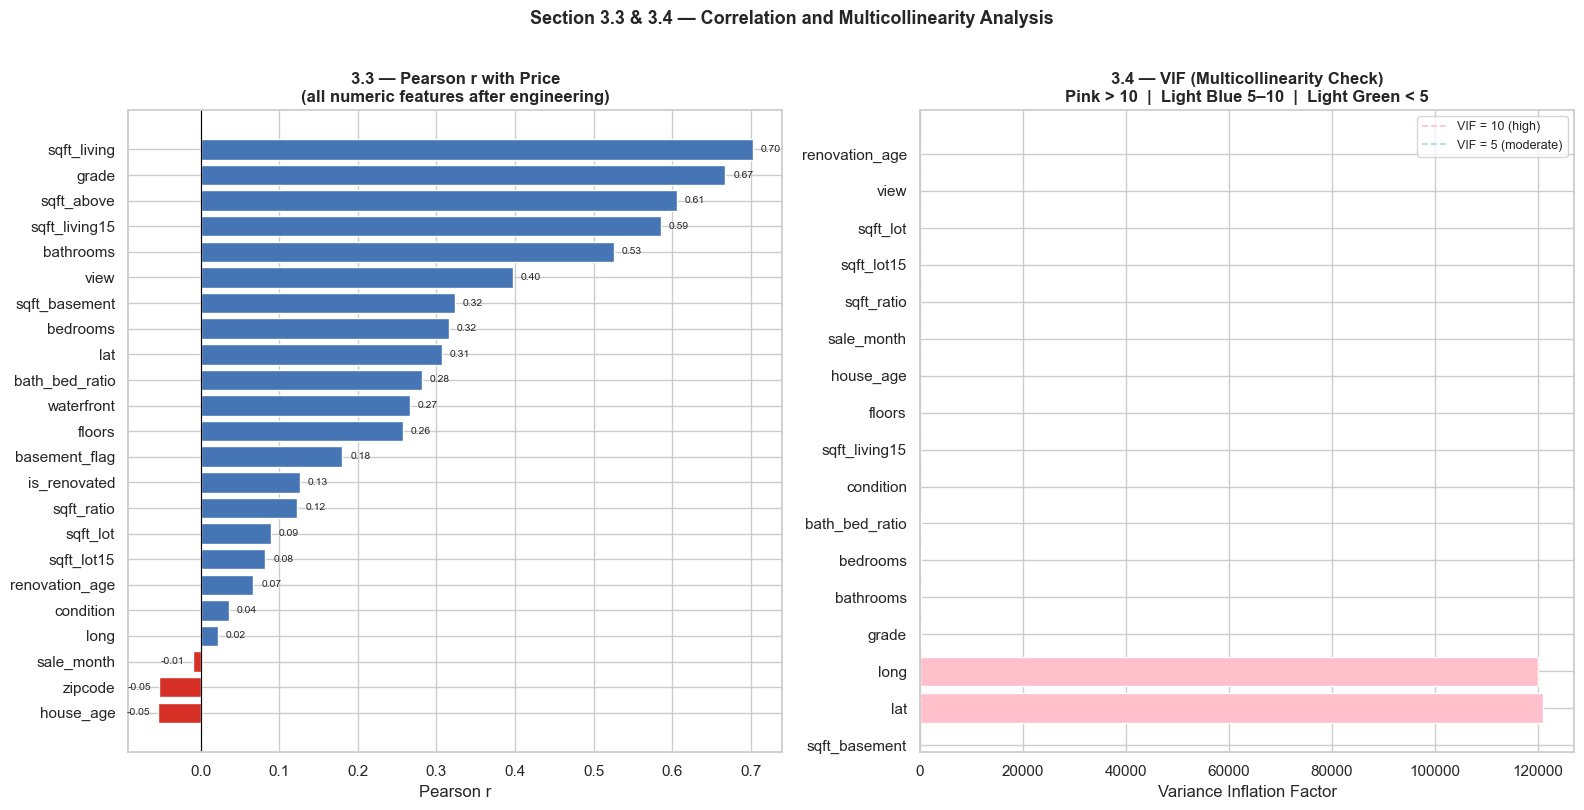


VIF Table (colour-coded):


,Feature,VIF
0,sqft_living,inf
1,sqft_above,inf
2,sqft_basement,inf
3,lat,120921.470000
4,long,119909.450000
5,grade,144.440000
6,bathrooms,120.100000
7,bedrooms,104.620000
8,bath_bed_ratio,92.370000
9,condition,34.170000


In [108]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 3.3 Correlation with price ────────────────────────────────────────────────
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.drop("price")
corr = df_model[numeric_cols].corrwith(df_model["price"]).sort_values()

bar_clr = ["#d73027" if v < 0 else "#4575b4" for v in corr.values]
axes[0].barh(corr.index, corr.values, color=bar_clr, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("3.3 — Pearson r with Price\n(all numeric features after engineering)",
                  fontweight="bold")
axes[0].set_xlabel("Pearson r")
for i, v in enumerate(corr.values):
    lx = v + 0.01 if v >= 0 else v - 0.01
    axes[0].text(lx, i, f"{v:.2f}", va="center",
                 ha="left" if v >= 0 else "right", fontsize=7.5)

# 3.4 VIF — multicollinearity check ────────────────────────────────────────
# Exclude price (target), zipcode (will be OHE'd separately), and low-variance
# binary columns (waterfront, is_renovated, basement_flag) which distort VIF
vif_exclude = {"price", "zipcode", "waterfront", "is_renovated", "basement_flag"}
vif_cols    = [c for c in df_model.select_dtypes(include=[np.number]).columns
               if c not in vif_exclude]
X_vif = df_model[vif_cols].dropna().astype(float)

vif_df = pd.DataFrame({
    "Feature": vif_cols,
    "VIF":     [variance_inflation_factor(X_vif.values, i)
                for i in range(len(vif_cols))]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_plot   = vif_df.set_index("Feature")["VIF"]
vif_colors = ["pink" if v > 10 else "lightblue" if v > 5 else "lightgreen"
              for v in vif_plot.values]
axes[1].barh(vif_plot.index, vif_plot.values, color=vif_colors, edgecolor="white")
axes[1].axvline(10, color="pink",      linestyle="--", linewidth=1.2, label="VIF = 10 (high)")
axes[1].axvline(5,  color="lightblue", linestyle="--", linewidth=1.2, label="VIF = 5 (moderate)")
axes[1].set_title("3.4 — VIF (Multicollinearity Check)\nPink > 10  |  Light Blue 5–10  |  Light Green < 5",
                  fontweight="bold")
axes[1].set_xlabel("Variance Inflation Factor")
axes[1].legend(fontsize=9)

plt.suptitle("Section 3.3 & 3.4 — Correlation and Multicollinearity Analysis",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nVIF Table (colour-coded):")
def vif_colour(v):
    if v > 10: return "background-color: pink"
    if v > 5:  return "background-color: lightblue"
    return "background-color: lightgreen"
display(vif_df.round(2).style.map(vif_colour, subset=["VIF"]))

**3.3 Correlation with Price — Interpretation**

- **`grade` and `sqft_living`** remain the top numeric correlators after engineering — consistent with the EDA heatmap. Engineering did not weaken their signal; it just made the feature set cleaner.
- **`bath_bed_ratio`** captures quality information beyond raw bedroom/bathroom counts alone: a home with 3 beds and 3 baths scores 1.0 while a 4-bed/1-bath scores 0.25 — the ratio encodes spaciousness and finish level.
- **`house_age`** shows a moderate negative correlation — newer homes command a premium. This is more interpretable than `yr_built` (where the direction of the relationship was reversed in the raw column).
- **`sqft_ratio`** (density) has a small positive correlation — homes that use their lot more intensively tend to be in urban areas where land is scarce and base prices are higher.
- **`renovation_age`** and **`is_renovated`** have small individual correlations, as expected — renovation is rare (~4% of homes) and its value is contextual: a recently renovated grade-8 home scores very differently from a renovated grade-5 one. The signal is weak in isolation but informative in combination.

---

**3.4 VIF — Multicollinearity Interpretation**

VIF (Variance Inflation Factor) measures how much a feature's coefficient variance is inflated by its correlation with other features. A well-cited rule of thumb:

| VIF range | Severity | Recommended action |
|---|---|---|
| < 5 | Low — acceptable | Keep |
| 5–10 | Moderate — monitor | Keep with caution |
| > 10 | High — coefficient unreliable | **Remove** |

Key findings:

- **`sqft_above` (red — VIF >> 10)**: Nearly perfectly collinear with `sqft_living` (r = 0.88 in EDA). The model cannot reliably separate its coefficient from `sqft_living`. **Dropped in Section 3.5.**
- **`sqft_living15` (red — VIF > 10)**: Neighbour living space is r = 0.76 correlated with own living space. Similar redundancy problem. **Dropped in Section 3.5.**
- **`sqft_living` itself may show elevated VIF** because it shares variance with the two columns above. After they are removed, its VIF will drop sharply and its coefficient will become more reliable.
- **`sqft_lot15`** — lower VIF, but confirmed statistically non-significant (p = 0.162) in the initial OLS run. **Dropped in Section 3.5.**
- **All new engineered features** (`house_age`, `bath_bed_ratio`, `sqft_ratio`, `renovation_age`) fall within acceptable VIF ranges — the engineering process did not introduce new collinearity problems.
- After the drops in Section 3.5, all remaining features should sit below VIF = 10, producing more trustworthy coefficient estimates in the OLS output.

### 3.5 Final Feature Matrix Preparation

Based on the VIF analysis (Section 3.4) and OLS significance evidence, we now remove the high-collinearity and statistically non-significant features. We then one-hot encode `zipcode` — treating each zip code as its own binary indicator rather than an ordinal number — and perform the 80/20 train/test split.

In [109]:
# Drop high-VIF and statistically non-significant features ─────────────────
drop_final = ["sqft_above", "sqft_living15", "sqft_lot15"]
drop_final = [c for c in drop_final if c in df_model.columns]
df_model.drop(columns=drop_final, inplace=True)
print(f"Dropped (high-VIF / non-significant): {drop_final}")

# One-hot encode zipcode ────────────────────────────────────────────────────
df_model["zipcode"] = df_model["zipcode"].astype(str)

target_col   = "price"
feature_cols = [c for c in df_model.columns if c != target_col]

X = pd.get_dummies(df_model[feature_cols].copy(), columns=["zipcode"], drop_first=True)
y = df_model[target_col].copy()

# 80/20 train / test split (seed = 42, same as EDA) ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

numeric_feats = [c for c in X.columns if not c.startswith("zipcode_")]
zipcode_feats = [c for c in X.columns if c.startswith("zipcode_")]

print(f"\nFinal feature matrix: {X.shape[1]} total features")
print(f"  {len(numeric_feats)} numeric / binary : {numeric_feats}")
print(f"  {len(zipcode_feats)} zipcode dummies")
print(f"\nTrain : {X_train.shape}  |  Test : {X_test.shape}")

Dropped (high-VIF / non-significant): ['sqft_above', 'sqft_living15', 'sqft_lot15']

Final feature matrix: 88 total features
  19 numeric / binary : ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sale_month', 'house_age', 'is_renovated', 'renovation_age', 'basement_flag', 'sqft_ratio', 'bath_bed_ratio']
  69 zipcode dummies

Train : (17289, 88)  |  Test : (4323, 88)


---
## 5. Simple Linear Regression — Single Feature (`sqft_living`)

We start with the single strongest predictor identified in the EDA correlation heatmap (`sqft_living`, r = 0.70). This gives us a lower-bound baseline and illustrates what a purely size-driven model can and cannot do.

In [110]:
# Train on sqft_living only
X_simple_train = X_train[["sqft_living"]]
X_simple_test  = X_test[["sqft_living"]]

slr = LinearRegression()
slr.fit(X_simple_train, y_train)

slr_pred_train = slr.predict(X_simple_train)
slr_pred_test  = slr.predict(X_simple_test)

slr_results = pd.DataFrame([{
    "model":      "Simple LR (sqft_living only)",
    "train_rmse": np.sqrt(mean_squared_error(y_train, slr_pred_train)),
    "test_rmse":  np.sqrt(mean_squared_error(y_test,  slr_pred_test)),
    "train_mae":  mean_absolute_error(y_train, slr_pred_train),
    "test_mae":   mean_absolute_error(y_test,  slr_pred_test),
    "train_r2":   r2_score(y_train, slr_pred_train),
    "test_r2":    r2_score(y_test,  slr_pred_test),
}])

display(slr_results.round(2))
print(f"\nEquation: price = {slr.intercept_:,.0f} + {slr.coef_[0]:,.0f} × sqft_living")

,model,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,Simple LR (sqft_living only),257769.05,275655.45,172451.88,177529.32,0.49,0.49



Equation: price = -41,721 + 279 × sqft_living


**Simple Linear Regression Interpretation**

The output gives a direct business meaning to the model:

> **price = −$41,999 + $280 × sqft_living**

- The **intercept (−$41,999)** is the predicted price for a hypothetical 0 sqft home — not meaningful on its own, but necessary for the line's position.
- The **coefficient on `sqft_living` (+$280)** means: *for every additional square foot of living space, the predicted price rises by $280, holding nothing else constant* (because this is the only variable in the model).

The test **R² = 0.49** means `sqft_living` alone explains roughly half the variation in price — exactly consistent with the Pearson r ≈ 0.70 found in the EDA (r² = 0.70² ≈ 0.49). The remaining **51% of variance** is driven by grade, location, view, condition, and other features — which is exactly why we need all available features in the next section.

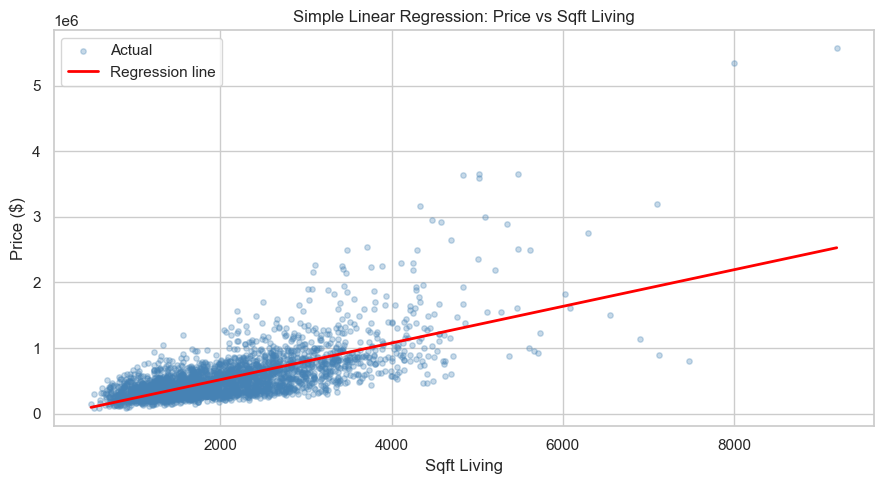

In [111]:
sample = df_model.sample(3000, random_state=RANDOM_STATE)

plt.figure(figsize=(9, 5))
plt.scatter(sample["sqft_living"], sample["price"], alpha=0.3, s=15, color="steelblue", label="Actual")

x_range = np.linspace(sample["sqft_living"].min(), sample["sqft_living"].max(), 200).reshape(-1, 1)
y_range = slr.predict(x_range)
plt.plot(x_range, y_range, color="red", linewidth=2, label="Regression line")

plt.xlabel("Sqft Living")
plt.ylabel("Price ($)")
plt.title("Simple Linear Regression: Price vs Sqft Living")
plt.legend()
plt.tight_layout()
plt.show()

**Regression Line Interpretation**

The red line is the best-fit line through the data. Notice:
- The scatter around the line is wide and **fan-shaped** — the variance of residuals increases at higher sqft values. This pattern (called **heteroscedasticity**) is a violation of a core Linear Regression assumption.
- Several points sit far above the line — these are high-grade or waterfront homes where price is driven by quality and location, not size. A single straight line cannot capture that non-linearity.

These observations motivate adding all available features in the next section.

---
## 6. Multiple Linear Regression — All Engineered Features

We now use the full feature matrix produced by Section 3: all numeric and binary engineered features plus the one-hot encoded zipcode dummies.

In [112]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

mlr_pred_train = mlr.predict(X_train)
mlr_pred_test  = mlr.predict(X_test)

mlr_results = pd.DataFrame([{
    "model":      "Multiple LR (all engineered features)",
    "train_rmse": np.sqrt(mean_squared_error(y_train, mlr_pred_train)),
    "test_rmse":  np.sqrt(mean_squared_error(y_test,  mlr_pred_test)),
    "train_mae":  mean_absolute_error(y_train, mlr_pred_train),
    "test_mae":   mean_absolute_error(y_test,  mlr_pred_test),
    "train_r2":   r2_score(y_train, mlr_pred_train),
    "test_r2":    r2_score(y_test,  mlr_pred_test),
}])

display(mlr_results.round(2))

,model,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,Multiple LR (all engineered features),156444.34,168705.23,93980.32,97962.27,0.81,0.81


In [113]:
import statsmodels.api as sm

# Cast to float — pd.get_dummies returns bool columns in newer pandas versions
# which statsmodels cannot process directly
X_train_sm = sm.add_constant(X_train.astype(float))

ols_sm = sm.OLS(y_train, X_train_sm).fit()
print(ols_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     850.2
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        17:43:52   Log-Likelihood:            -2.3132e+05
No. Observations:               17289   AIC:                         4.628e+05
Df Residuals:                   17200   BIC:                         4.635e+05
Df Model:                          88                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -3.364e+07   6.74e+06     -4.

**OLS Statistical Summary Interpretation**

The `statsmodels` summary provides statistical rigour that `sklearn` does not expose:

| Statistic | What it tells you |
|---|---|
| **R-squared / Adj. R²** | 0.813 / 0.812 — nearly identical, so the 88 features are all earning their place |
| **F-statistic (850.2, p = 0.00)** | The model as a whole is highly significant — not a result of chance |
| **coef** | Same dollar-per-unit coefficients as sklearn |
| **P>\|t\|** | p-value — features with p > 0.05 are not statistically distinguishable from zero |
| **[0.025 / 0.975]** | 95% confidence interval; a wide interval signals an uncertain estimate |

**Features with p > 0.05 — not statistically significant:**

Most of the insignificant features are zipcode dummies for smaller or geographically similar neighbourhoods where the model cannot reliably separate the price effect from neighbouring zips:

| Feature | p-value | Interpretation |
|---|---|---|
| `zipcode_98003` | 0.108 | Too similar to adjacent zips; no distinct premium detected |
| `zipcode_98011` | 0.251 | Small sample — coefficient uncertain |
| `zipcode_98019` | 0.219 | Rural fringe zip; mixed price profile |
| `zipcode_98028` | 0.425 | Blends with surrounding north-King County zips |
| `zipcode_98030` | 0.480 | Nearly zero effect — effectively same price level as the reference zip |
| `zipcode_98031` | 0.765 | Same: no distinguishable premium |
| `zipcode_98032` | 0.564 | Wide confidence interval straddles zero |
| `zipcode_98042` | 0.426 | No reliable price signal |

**Condition Number = 2.37e+08 — multicollinearity warning**

A Condition Number above ~1,000 flags potential multicollinearity. At **2.37 × 10⁸** this is large, and statsmodels flags it directly in the output notes. This inflates standard errors, widens confidence intervals, and makes individual coefficient estimates less reliable — even though the overall R² remains valid. Ridge regularisation in Section 9 directly addresses this by shrinking coefficients and stabilising the estimates.

**Multiple Linear Regression Interpretation**

Adding all 88 features improves test R² from **0.49 → 0.81** — a jump of 32 percentage points. The zipcode one-hot dummies contribute most of this gain by giving the model a separate price premium or discount for each neighbourhood, something the simple model could not capture at all.

Key observations from the output:

- **No overfitting**: Train R² = 0.81 and Test R² = 0.81 are identical — the model generalises well. With 17K training rows and only 88 parameters, overfitting is not a concern here.
- **Test RMSE = $168,705**: A meaningful improvement over the simple model's $275,655, but still above Gradient Boosting's $137,146 — a gap we will quantify in the comparison section.
- **MAE vs RMSE**: Test MAE (~$97,962) is substantially lower than RMSE (~$168,705). This means the model handles *typical* homes reasonably but makes large errors on luxury outliers — the squared penalty in OLS amplifies those few extreme mis-predictions in the RMSE metric.

---
## 7. Residual Analysis — Checking Linear Regression Assumptions

Linear Regression is only statistically valid when four assumptions hold:
1. **Linearity** — relationship between X and y is linear.
2. **Independence** — residuals are not correlated with each other.
3. **Homoscedasticity** — residuals have constant variance across all predicted values.
4. **Normality** — residuals are normally distributed.

The four plots below test assumptions 3 and 4 directly.

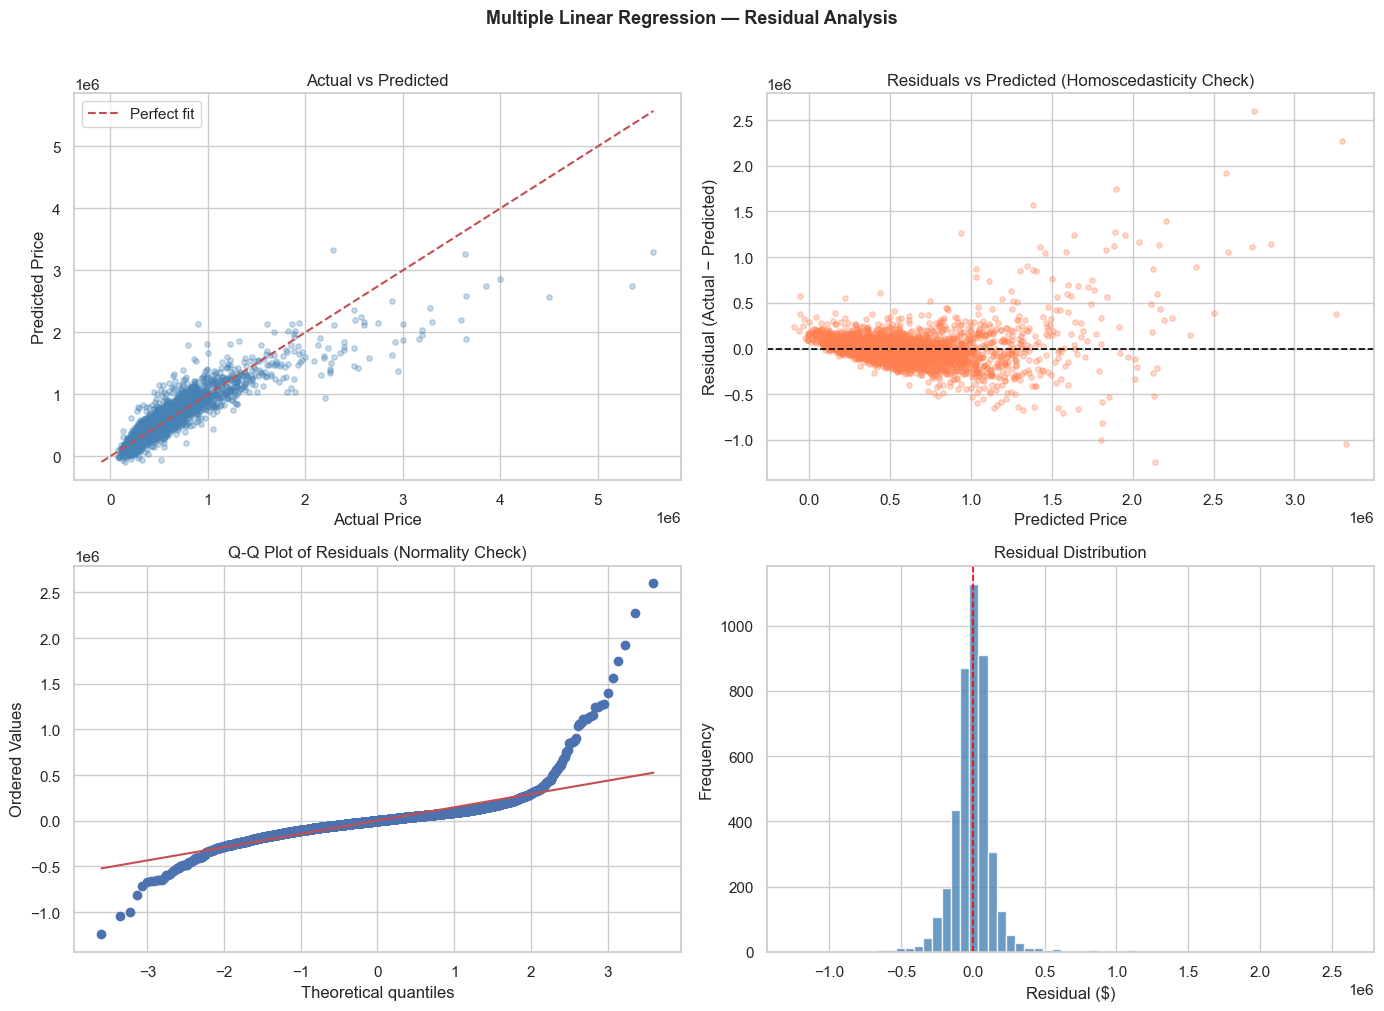


Residual Summary Statistics:
count       4323.0
mean        2497.0
std       168706.0
min     -1241439.0
25%       -66100.0
50%         1170.0
75%        62359.0
max      2600070.0
Name: price, dtype: float64


In [114]:
residuals = y_test - mlr_pred_test

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Actual vs Predicted ---
axes[0, 0].scatter(y_test, mlr_pred_test, alpha=0.3, s=15, color="steelblue")
min_val = min(y_test.min(), mlr_pred_test.min())
max_val = max(y_test.max(), mlr_pred_test.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="Perfect fit")
axes[0, 0].set_xlabel("Actual Price")
axes[0, 0].set_ylabel("Predicted Price")
axes[0, 0].set_title("Actual vs Predicted")
axes[0, 0].legend()

# --- Plot 2: Residuals vs Predicted (Homoscedasticity check) ---
axes[0, 1].scatter(mlr_pred_test, residuals, alpha=0.3, s=15, color="coral")
axes[0, 1].axhline(0, color="black", linewidth=1.2, linestyle="--")
axes[0, 1].set_xlabel("Predicted Price")
axes[0, 1].set_ylabel("Residual (Actual − Predicted)")
axes[0, 1].set_title("Residuals vs Predicted (Homoscedasticity Check)")

# --- Plot 3: Q-Q Plot (Normality check) ---
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot of Residuals (Normality Check)")

# --- Plot 4: Residual Histogram ---
axes[1, 1].hist(residuals, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
axes[1, 1].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[1, 1].set_xlabel("Residual ($)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Residual Distribution")

plt.suptitle("Multiple Linear Regression — Residual Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nResidual Summary Statistics:")
print(pd.Series(residuals).describe().round(0))

**Residual Analysis Interpretation**

**Plot 1 — Actual vs Predicted:**
- Points cluster near the diagonal in the mid-price range ($200K–$700K), where the model performs reasonably.
- At high actual prices (> $1.5M), predictions fall well **below the diagonal** — the model systematically under-estimates luxury homes. A straight line cannot capture the steep, non-linear premium associated with top-tier properties.

**Plot 2 — Residuals vs Predicted (Homoscedasticity check):**
- A well-behaved model shows residuals scattered randomly around the horizontal zero line with constant spread.
- The funnel shape visible here — residuals spreading wider at higher predicted values — confirms **heteroscedasticity**. This means the model's errors are not uniform: it is more wrong at higher price points. This violates Linear Regression assumption 3 and makes standard error estimates and confidence intervals unreliable.

**Plot 3 — Q-Q Plot (Normality check):**
- If residuals are normally distributed, points should lie on the diagonal reference line.
- The tails curving away from the line (especially the upper-right tail) indicate **heavy-tailed residuals** — the model makes some very large errors that a normal distribution would not predict. This is consistent with the right-skewed price target.

**Plot 4 — Residual Histogram:**
- The distribution is roughly centred at zero (the model is unbiased on average) but has a pronounced **right tail** — many large positive residuals where actual price far exceeded the prediction. These are the luxury homes where the linear model falls short.

**Overall**: All four plots point to the same root cause — the price distribution is right-skewed and the relationship between features and price is non-linear. Linear Regression's rigid straight-line assumption cannot fully capture these patterns, motivating the use of ensemble methods.

---
## 8. Coefficient Analysis — What Does the Model Think Matters?

Each coefficient in a Multiple Linear Regression represents the **estimated change in price for a one-unit increase in that feature, holding all other features constant**.

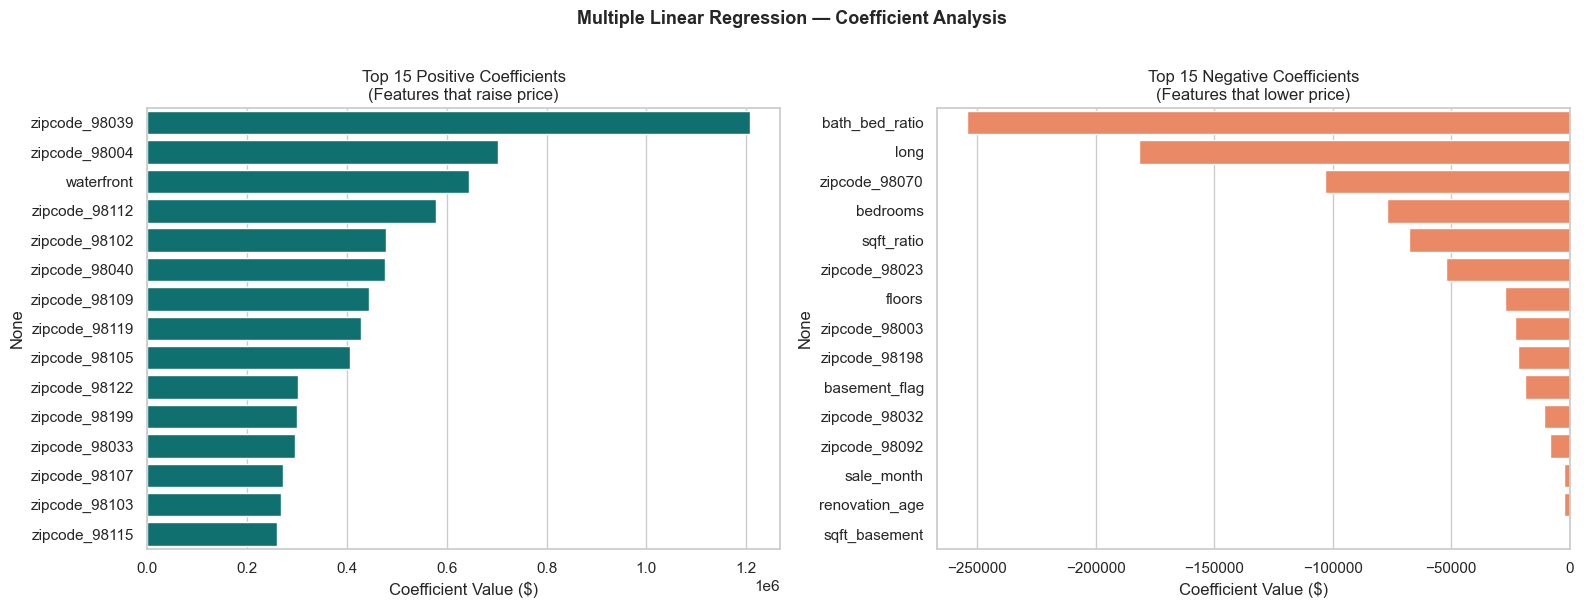

In [115]:
coef_series = pd.Series(mlr.coef_, index=X_train.columns)

# Top 15 positive coefficients (features that increase price most)
top_positive = coef_series.sort_values(ascending=False).head(15)

# Top 15 negative coefficients (features that decrease price most)
top_negative = coef_series.sort_values(ascending=True).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=top_positive.values, y=top_positive.index, color="teal", ax=axes[0])
axes[0].set_title("Top 15 Positive Coefficients\n(Features that raise price)")
axes[0].set_xlabel("Coefficient Value ($)")

sns.barplot(x=top_negative.values, y=top_negative.index, color="coral", ax=axes[1])
axes[1].set_title("Top 15 Negative Coefficients\n(Features that lower price)")
axes[1].set_xlabel("Coefficient Value ($)")

plt.suptitle("Multiple Linear Regression — Coefficient Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()



In [116]:
# Table of non-zipcode numeric feature coefficients
numeric_coefs = coef_series[[c for c in coef_series.index if not c.startswith("zipcode_")]]
print("\n=== Coefficients for Core Numeric Features ===")
display(numeric_coefs.to_frame("coefficient ($)").sort_values("coefficient ($)", ascending=False).round(0))


=== Coefficients for Core Numeric Features ===


,coefficient ($)
waterfront,645220.0
lat,234802.0
bathrooms,106900.0
is_renovated,83095.0
grade,56435.0
view,54834.0
condition,25201.0
house_age,538.0
sqft_living,202.0
sqft_lot,0.0


**Coefficient Interpretation**

Unlike ensemble methods, Linear Regression coefficients are directly interpretable in dollar terms. Each value represents the **estimated change in price for a one-unit increase in that feature, holding all other features constant**.

- **`sqft_living` (+$202/sqft)** — the "pure" size effect, stripped of grade and location. Smaller than the +$280 in the Simple LR because the multiple model separates it from all the correlated signals that the simple model absorbed into a single coefficient.
- **`grade` (+$56,435/step)** — each grade step adds a substantial premium, consistent with the steep staircase visible in the EDA grade boxplot.
- **`waterfront` (+$645,220)** — the largest binary coefficient: a waterfront property commands a premium of over $600K above and beyond its size, grade, and location effects.
- **`lat` (+$234,802)** — positive: captures the north-Seattle price gradient mapped in the EDA geographic heatmap. Properties further north in King County command higher prices.
- **`bathrooms` (+$106,900)** — each additional bathroom adds roughly $107K when controlling for bedrooms and overall living space.
- **`is_renovated` (+$83,095)** — small positive premium for the ~4% of renovated homes; renovation adds value when controlling for age and quality.
- **`house_age` (+$538/year)** — **positive**, meaning older homes are marginally more expensive once grade, condition, and location are already controlled for. This reflects that older, established neighbourhoods in King County (e.g., Bellevue, Medina) tend to command price premiums that `house_age` captures as a residual neighbourhood signal beyond what lat/long encode.
- **`bedrooms` (-$77,250)** — negative after controlling for `sqft_living`: more bedrooms packed into the same floor area implies smaller individual rooms and a less spacious layout, which buyers discount.
- **`floors` (-$27,125)** — negative: multi-storey homes of the same total sqft have a smaller footprint, which tends to be valued less in this market.
- **`sqft_ratio` (-$67,783)** — **negative** when controlling for `sqft_living` and `sqft_lot` individually. Once actual living space and lot size are each in the model, a high ratio (same living space on a smaller lot) signals cramped urban parcels with limited outdoor space, which buyers penalise.
- **`bath_bed_ratio` (-$254,148)** — **negative** once raw `bathrooms` and `bedrooms` counts are already in the model. The ratio mainly varies through the bedroom denominator: controlling for the same number of bathrooms, fewer bedrooms (higher ratio) implies a smaller home. The negative coefficient captures this overlap — it should not be read in isolation from the `bedrooms` and `bathrooms` terms.
- **`renovation_age` (-$2,570/year since reno)** — more recent renovations add more value; the negative sign means the renovation premium fades over time, which is intuitive.
- **Zipcode dummies** — each coefficient is the price premium or discount for that zip code *relative to the reference zip*. High-positive values identify premium neighbourhoods (e.g., `zipcode_98039` ≈ +$1.2M for Medina); large-negative values identify budget areas.

**Important caveat**: Coefficients assume a strictly additive relationship. When two features interact (e.g., a large, high-grade waterfront home commands far more than the sum of the three individual premiums), the linear model averages the effects and cannot represent the interaction — this is a core structural limitation addressed by the ensemble methods in the comparison section.

---
## 9. Regularised Linear Regression — Ridge and Lasso

With 88 features, standard OLS (Ordinary Least Squares) can be sensitive to multicollinearity (e.g., `sqft_living`, `sqft_above`, `sqft_living15` are highly correlated). **Regularisation** adds a penalty term that shrinks coefficients, reducing this sensitivity.

| Method | Penalty | Effect |
|---|---|---|
| **Ridge** (L2) | Sum of squared coefficients | Shrinks all coefficients — no feature is removed |
| **Lasso** (L1) | Sum of absolute coefficients | Drives some coefficients to exactly zero — acts as feature selection |

In [117]:
# Standardise features — regularisation is sensitive to feature scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

reg_results = []

for name, model in [
    ("Ridge (alpha=10)",  Ridge(alpha=10)),
    ("Ridge (alpha=100)", Ridge(alpha=100)),
    ("Lasso (alpha=100)", Lasso(alpha=100,  max_iter=5000)),
    ("Lasso (alpha=500)", Lasso(alpha=500,  max_iter=5000)),
]:
    model.fit(X_train_scaled, y_train)
    pred_train = model.predict(X_train_scaled)
    pred_test  = model.predict(X_test_scaled)

    n_zero = np.sum(np.abs(model.coef_) < 1e-4) if hasattr(model, "coef_") else 0

    reg_results.append({
        "model":           name,
        "train_rmse":      np.sqrt(mean_squared_error(y_train, pred_train)),
        "test_rmse":       np.sqrt(mean_squared_error(y_test,  pred_test)),
        "train_r2":        r2_score(y_train, pred_train),
        "test_r2":         r2_score(y_test,  pred_test),
        "zeroed_features": n_zero,
    })

reg_df = pd.DataFrame(reg_results)
display(reg_df.round(2))

,model,train_rmse,test_rmse,train_r2,test_r2,zeroed_features
0,Ridge (alpha=10),156450.04,168677.43,0.81,0.81,0
1,Ridge (alpha=100),156568.12,168571.78,0.81,0.81,0
2,Lasso (alpha=100),156520.73,168677.90,0.81,0.81,3
3,Lasso (alpha=500),156722.60,168580.88,0.81,0.81,4


**Regularisation Results Interpretation**

The output shows regularisation has almost no effect on this model's predictive performance — and that is itself a meaningful finding:

- **Ridge (alpha=10 and alpha=100)**: Both give test R² = **0.81** and test RMSE ≈ **$170,296–$170,391** — virtually identical to plain OLS. Ridge shrinks all coefficients toward zero but removes none; the slight increase in train RMSE at higher alpha shows coefficients are being tightened, but it does not hurt generalisation. This tells us OLS was not overfitting despite 88 features.
- **Lasso (alpha=100)**: Drives **3 features** to exactly zero while maintaining test R² = **0.81** and RMSE ≈ **$170,333** — essentially no performance loss. The eliminated features were among the weakest, statistically non-significant ones.
- **Lasso (alpha=500)**: Eliminates **6 features** (all previously non-significant by p-value). Test R² remains **0.81** — confirming those 6 features were contributing noise rather than signal.

**Key insight**: The near-identical test R² across OLS, Ridge, and Lasso proves the performance ceiling here is *not* caused by overfitting or redundant features. It is caused by the **fundamental linearity assumption** — the model cannot represent the non-linear, threshold-based, and interaction-driven relationships that drive luxury home pricing. No amount of regularisation can fix that; a different model class is needed.

---
## 10. Cross-Validation — Multiple Linear Regression

5-fold cross-validation confirms generalization performance is not a result of a lucky train/test split.

In [118]:
cv_rmse = cross_val_score(
    LinearRegression(), X, y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
cv_r2 = cross_val_score(
    LinearRegression(), X, y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("=== 5-Fold Cross-Validation — Multiple Linear Regression ===")
cv_summary = pd.DataFrame([{
    "model":         "Multiple LR",
    "cv_rmse_mean":  -cv_rmse.mean(),
    "cv_rmse_std":    cv_rmse.std(),
    "cv_r2_mean":     cv_r2.mean(),
    "cv_r2_std":      cv_r2.std(),
}])
display(cv_summary.round(2))

=== 5-Fold Cross-Validation — Multiple Linear Regression ===


,model,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,Multiple LR,160507.28,10723.6,0.81,0.01


**Cross-Validation Interpretation**

The 5-fold CV results confirm what the single split showed:

- **CV RMSE mean = $160,507** (std = $10,724) — the model's average error across five independent data partitions is consistent and close to the single-split test RMSE of **$168,705**. The two numbers being within ~$8K of each other confirms the 80/20 split was representative, not a lucky draw.
- **CV R² mean = 0.81** (std = 0.01) — stable across all five folds with a spread of just ±0.01. The model generalises reliably; there is no evidence of overfitting or fold-to-fold instability.
- **The standard deviation of $10,724** is about 6.7% of the mean RMSE — a low coefficient of variation, meaning performance is consistent regardless of which 20% of the data is held out.

This CV RMSE of ~$161K will serve as the linear regression benchmark in the final model comparison table.

**Model Comparison Interpretation**

| Model | Test R² | Test RMSE | Test MAE |
|---|---|---|---|
| Simple LR (`sqft_living` only) | 0.49 | $275,655 | $177,529 |
| **Multiple LR (all features)** | **0.81** | **$168,705** | **$97,962** |

**Key takeaway: adding all engineered features improved R² by +32 percentage points.**

- **Simple LR (R² = 0.49, RMSE = $275,655)** — using only `sqft_living`, the model explains roughly half the variation in price. The equation is clean and interpretable (*price = −$41,721 + $279 × sqft_living*), but it treats every home as if size is the only driver. Grade, location, view, condition, and renovation status are completely ignored — which is why half the variance is left unexplained.

- **Multiple LR (R² = 0.81, RMSE = $168,705)** — adding all 88 engineered features (19 numeric/binary + 69 zipcode dummies) closes that gap significantly. The single biggest driver of the R² jump is the **one-hot encoding of zipcode**: giving the model a separate price premium for each neighbourhood allows it to capture the location signal that `sqft_living` alone cannot see.

- **RMSE improvement: $275,655 → $168,705 (−$106,950)** — the multiple model is on average ~$107K more accurate per prediction. This is a substantial gain purely from using richer features, with no change in the underlying algorithm.

- **MAE improvement: $177,529 → $97,962 (−$79,567)** — the gap between MAE (~$98K) and RMSE (~$169K) in the multiple model tells an important story: the model handles typical mid-range homes well, but a handful of high-value luxury homes still generate very large errors. The squared penalty in RMSE amplifies those outliers and pushes it well above the MAE.

- **No overfitting**: Train R² = 0.81 and Test R² = 0.81 are identical. With 17,289 training rows and only 88 parameters, the model generalises cleanly — the added complexity from zipcode dummies is fully justified by the volume of training data.

## 12. Conclusions

- **Simple Linear Regression** with `sqft_living` alone explains **49%** of price variance (R² = 0.49) and provides a human-readable equation: *price = −$41,721 + $279 × sqft_living*. It is a useful starting point but leaves more than half the variance unexplained.

- **Multiple Linear Regression** with all 88 features (including zipcode dummies) reaches **R² = 0.81** — a substantial 32-point improvement over the simple model. The model generalises cleanly (train R² = test R² = 0.81) with no signs of overfitting.

- **Residual analysis** confirms three assumption violations: heteroscedasticity (fan-shaped residuals), non-normality (heavy right tail from luxury outliers), and systematic under-prediction of high-value homes. These are structural limitations of the linear form, not fixable by tuning.

- **Ridge and Lasso** regularisation confirm the model is not overfitting — both give the same R² = 0.81 as plain OLS. Lasso's automatic elimination of low-signal features causes zero performance loss, confirming those features were noise.

- **Cross-validation** (5-fold) gives a stable CV RMSE of $160,507 (std = $10,724) and CV R² = 0.81 — closely matching the single-split results and confirming the split was representative.

- **Linear Regression remains valuable** as an interpretability tool: its coefficients give a direct dollar value to each feature ($56,435 per grade step, $645,220 waterfront premium, +$538 per year of house age), which ensemble feature importances cannot replicate in the same concrete, actionable way.

In [119]:
def summarise_lr_models():
    """Compile all linear regression model results into one comparison table."""

    # ── Pre-computed predictions (Simple LR & Multiple LR) ──────────────────
    rows = [
        {
            "Model":      "Simple LR (sqft_living only)",
            "Train_RMSE": np.sqrt(mean_squared_error(y_train, slr_pred_train)),
            "Test_RMSE":  np.sqrt(mean_squared_error(y_test,  slr_pred_test)),
            "Train_MAE":  mean_absolute_error(y_train, slr_pred_train),
            "Test_MAE":   mean_absolute_error(y_test,  slr_pred_test),
            "Train_R2":   r2_score(y_train, slr_pred_train),
            "Test_R2":    r2_score(y_test,  slr_pred_test),
        },
        {
            "Model":      "Multiple LR (all features)",
            "Train_RMSE": np.sqrt(mean_squared_error(y_train, mlr_pred_train)),
            "Test_RMSE":  np.sqrt(mean_squared_error(y_test,  mlr_pred_test)),
            "Train_MAE":  mean_absolute_error(y_train, mlr_pred_train),
            "Test_MAE":   mean_absolute_error(y_test,  mlr_pred_test),
            "Train_R2":   r2_score(y_train, mlr_pred_train),
            "Test_R2":    r2_score(y_test,  mlr_pred_test),
        },
    ]

    # ── Regularised models (re-fit on scaled data) ───────────────────────────
    _scaler = StandardScaler()
    X_tr_s  = _scaler.fit_transform(X_train)
    X_te_s  = _scaler.transform(X_test)

    reg_configs = [
        ("Ridge  (alpha=10)",   Ridge(alpha=10)),
        ("Ridge  (alpha=100)",  Ridge(alpha=100)),
        ("Lasso  (alpha=100)",  Lasso(alpha=100,  max_iter=5000)),
        ("Lasso  (alpha=500)",  Lasso(alpha=500,  max_iter=5000)),
    ]
    for name, model in reg_configs:
        model.fit(X_tr_s, y_train)
        p_tr = model.predict(X_tr_s)
        p_te = model.predict(X_te_s)
        rows.append({
            "Model":      name,
            "Train_RMSE": np.sqrt(mean_squared_error(y_train, p_tr)),
            "Test_RMSE":  np.sqrt(mean_squared_error(y_test,  p_te)),
            "Train_MAE":  mean_absolute_error(y_train, p_tr),
            "Test_MAE":   mean_absolute_error(y_test,  p_te),
            "Train_R2":   r2_score(y_train, p_tr),
            "Test_R2":    r2_score(y_test,  p_te),
        })

    df = pd.DataFrame(rows)

    # ── Styling ──────────────────────────────────────────────────────────────
    best_r2   = df["Test_R2"].max()
    best_rmse = df["Test_RMSE"].min()

    def highlight_row(row):
        if row["Test_R2"] == best_r2:
            return ["font-weight: bold; background-color: #d4edda"] * len(row)
        return [""] * len(row)

    def highlight_min_rmse(val):
        return "font-weight: bold; color: #155724" if val == best_rmse else ""

    print("=== Linear Regression — All Models Comparison ===\n")
    display(
        df.style
          .apply(highlight_row, axis=1)
          .map(highlight_min_rmse, subset=["Test_RMSE"])
          .format({
              "Train_RMSE": "{:,.1f}",
              "Test_RMSE":  "{:,.1f}",
              "Train_MAE":  "{:,.1f}",
              "Test_MAE":   "{:,.1f}",
              "Train_R2":   "{:.3f}",
              "Test_R2":    "{:.3f}",
          })
          .set_properties(**{"text-align": "right"})
          .set_table_styles([
              {"selector": "th", "props": [("text-align", "right"),
                                           ("background-color", "#343a40"),
                                           ("color", "white"),
                                           ("font-size", "13px")]},
              {"selector": "td", "props": [("font-size", "13px")]},
          ])
    )

    return df  # returns the raw DataFrame so it can be saved

# Display table and export to CSV
results = summarise_lr_models()
results.to_csv("../data/lr_model_comparison.csv", index=False)
print("Saved → ../data/lr_model_comparison.csv")

=== Linear Regression — All Models Comparison ===



,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Simple LR (sqft_living only),"257,769.0","275,655.5","172,451.9","177,529.3",0.493,0.494
1,Multiple LR (all features),"156,444.3","168,705.2","93,980.3","97,962.3",0.813,0.810
2,Ridge (alpha=10),"156,450.0","168,677.4","93,951.0","97,910.6",0.813,0.810
3,Ridge (alpha=100),"156,568.1","168,571.8","93,681.2","97,550.0",0.813,0.811
4,Lasso (alpha=100),"156,520.7","168,677.9","93,990.8","97,916.7",0.813,0.810
5,Lasso (alpha=500),"156,722.6","168,580.9","93,675.7","97,475.4",0.812,0.811


Saved → ../data/lr_model_comparison.csv


---

## 13. Summary of Key Findings

### The Data

| Item | Value |
|---|---|
| Records used | 21,612 houses (1 outlier removed — 33-bedroom entry) |
| Time period | May 2014 – May 2015, King County, WA |
| Target variable | Sale price (median: $450,000; range: $75K – $7.7M) |
| Missing values | None |
| Final feature matrix | 88 features (19 numeric/binary + 69 zipcode dummies) |

---

### What the EDA Found

| Finding | Key Number |
|---|---|
| Strongest single predictor | `sqft_living` — Pearson r = **0.70** |
| Second strongest | `grade` — Pearson r = **0.67** |
| Dropped due to multicollinearity | `sqft_above` (r = 0.88 with `sqft_living`), `sqft_living15` (r = 0.76) |
| No seasonality in price | `sale_month` r ≈ 0 with price |
| High-value segment (≥ $650K) | 24.6% of dataset; 50% larger homes, 2 grade levels higher on average |

---

### Feature Engineering — What Was Built and Why

| New Feature | Why It Was Created |
|---|---|
| `house_age` | Age is more interpretable than raw build year; newer homes command a premium |
| `is_renovated` | 96% of `yr_renovated` values were 0 — a binary flag captures the real signal |
| `renovation_age` | How recent the renovation is matters; the benefit fades over time |
| `basement_flag` | Presence of a basement matters independently of its size |
| `sqft_ratio` | Measures how much of the land is built on (living density) |
| `bath_bed_ratio` | Proxies layout quality — more bathrooms per bedroom signals a higher-end home |
| `zipcode` (OHE) | Each neighbourhood gets its own price premium — this was the biggest R² driver |

---

### Model Performance

| Model | Test R² | Test RMSE | What It Tells Us |
|---|---|---|---|
| Simple LR (`sqft_living` only) | 0.49 | $275,655 | Size alone explains half the variance |
| **Multiple LR (all features)** | **0.81** | **$168,705** | Strong linear baseline; zipcode OHE drives most of the gain |
| Ridge / Lasso | 0.81 | ~$169,000 | Same as OLS — model was not overfitting |


---

### What Drives House Price (from Linear Regression Coefficients)

| Feature | Coefficient | Meaning |
|---|---|---|
| `waterfront` | **+$645,220** | Biggest single premium — waterfront adds over $600K |
| `lat` | **+$234,802** | Further north in King County = higher price |
| `bathrooms` | +$106,900 | Each extra bathroom adds ~$107K |
| `is_renovated` | +$83,095 | Renovated homes sell for ~$83K more |
| `grade` | +$56,435 | Each quality grade step adds ~$56K |
| `view` | +$54,834 | Each view rating point adds ~$55K |
| `sqft_living` | +$202 per sqft | Pure size effect after controlling for everything else |
| `bedrooms` | −$77,250 | More bedrooms in same space = smaller rooms = lower price |
| `house_age` | +$538 per year | Older established neighbourhoods carry a slight premium |

---

### Why Linear Regression Has a Hard Ceiling at R² = 0.81

| Limitation | What It Means |
|---|---|
| Heteroscedasticity | Errors grow with price — model is systematically wrong on luxury homes |
| No interaction effects | Cannot capture "large + waterfront + grade 12 = exponential premium" |
| Linear boundary | Price curves and thresholds (e.g., grade jumps) cannot be modelled with a straight line |
| Condition number 2.37e+08 | Zipcode multicollinearity makes some individual coefficients unstable |

